In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/flights.csv"
df = pd.read_csv(url)

df.head()

,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121


In [2]:
df.rename(columns={'year': 'Order Date', 'month': 'Product', 'passengers': 'Sales'}, inplace=True)

# Add Category column
df['Category'] = ['Technology' if i%3==0 else 'Furniture' if i%3==1 else 'Office Supplies' for i in range(len(df))]

# Add Region column
df['Region'] = ['East' if i%4==0 else 'West' if i%4==1 else 'South' if i%4==2 else 'North' for i in range(len(df))]

df.head()

,Order Date,Product,Sales,Category,Region
0,1949,January,112,Technology,East
1,1949,February,118,Furniture,West
2,1949,March,132,Office Supplies,South
3,1949,April,129,Technology,North
4,1949,May,121,Furniture,East


In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%Y')


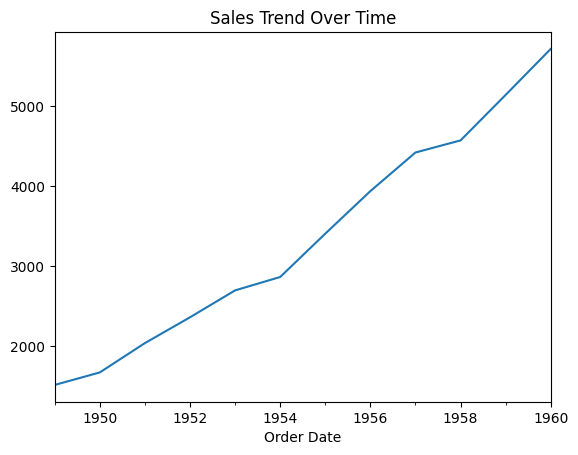

In [4]:
import matplotlib.pyplot as plt

sales_trend = df.groupby('Order Date')['Sales'].sum()

plt.figure()
sales_trend.plot()
plt.title("Sales Trend Over Time")
plt.show()

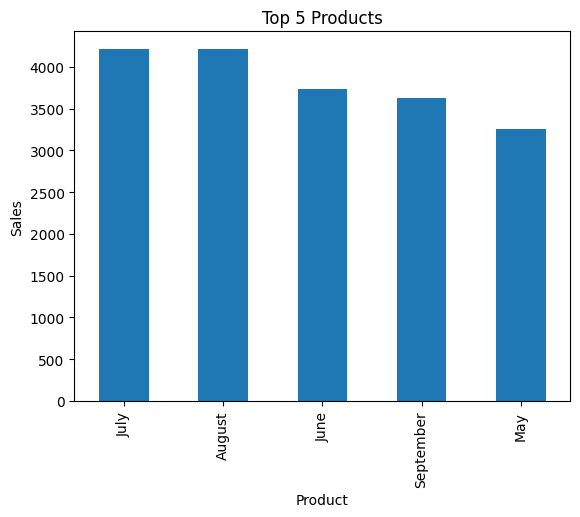

In [5]:
top_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(5)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 5 Products")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

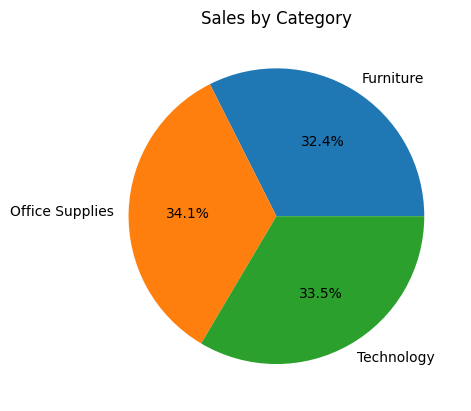

In [6]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure()
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Category")
plt.ylabel("")
plt.show()

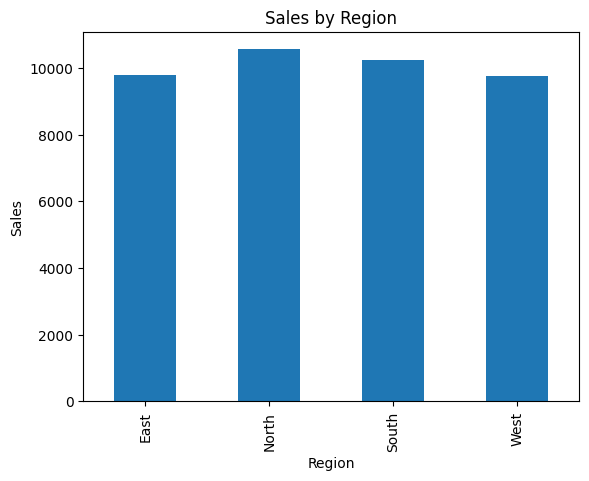

In [7]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure()
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

In [8]:
print("Top Product:", top_products.index[0])
print("Best Category:", category_sales.idxmax())
print("Top Region:", region_sales.idxmax())

print("\nConclusion:")
print("Sales are increasing over time.")
print("Certain products and regions perform better than others.")
print("Business should focus on high-performing areas to increase revenue.")

Top Product: July
Best Category: Office Supplies
Top Region: North

Conclusion:
Sales are increasing over time.
Certain products and regions perform better than others.
Business should focus on high-performing areas to increase revenue.
